In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from utils import tabulate_neatly
import SPDE
import yaml
import time

# Flags

Runs experiment for those which are set to true (~10min/experiment)

In [2]:
HEAT = True
NAGUMO = True
ALLEN_CAHN = True
KDV = True

DRIFT = True
DIFFUSION = True

MATCHED_SIZE = True
LIMIT_DERIVATIVES = False
LIMIT_POLYNOMIALS = True

RANDOM_INITIAL_CONDITIONS = True
GENERATE_PREDICTION_DATA = True
GENERATE_TRAINING_DATA = False
RUN_LASSO = True
RUN_SINDY = True

LEGENDRE_POLYNOMIALS = False

ALGORITHMS = {"Lasso": RUN_LASSO, "SINDy": RUN_SINDY}
IDENTIFICATION_TASKS = {"Drift": DRIFT, "Diffusion": DIFFUSION}

#### Generate Data

In [3]:
import DataGenerator as dg

experimentKeys = {"Heat": HEAT,
 "Nagumo": NAGUMO,
 "Allen_Cahn": ALLEN_CAHN,
 "KdV": KDV
 }

for key, value in experimentKeys.items():
    if value and GENERATE_TRAINING_DATA:
        dg.generateData(key, randomConditions=RANDOM_INITIAL_CONDITIONS)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


#### Mean of Dictionaries

In [4]:


with open("parameters.yaml") as f:
    yamlParameters = yaml.safe_load(f)

space = yamlParameters["common"]["x_end"] - yamlParameters["common"]["x_start"]
timeRange = yamlParameters["common"]["t_end"] - yamlParameters["common"]["t_start"]
timeSteps = yamlParameters["common"]["timesteps"]
spacePoints = yamlParameters["common"]["J"]
isPeriodic = yamlParameters["common"]["periodic"]

problemDictionaries = {}
problemDescriptions = {}

for key, value in experimentKeys.items():
    if value:   
        U = np.load(f'data/{key}_dx_{spacePoints}m_{timeSteps}t.npy')
        dx = space/(U.shape[0])
        dt = timeRange/(U.shape[1]-1)
        
        Dictt = []
        for i in range(U.shape[2]):
            if i%100==0:
                print(i)
            U_t,Di,description = SPDE.build_linear_system(U[:,:-1,i], dt, dx, D = 3 if LIMIT_DERIVATIVES else 6 if MATCHED_SIZE else 5, P = 3 if LIMIT_POLYNOMIALS else 6, periodic=isPeriodic, legendre=LEGENDRE_POLYNOMIALS)
            Dictt.append(Di)
        Dictt = np.mean(np.array(Dictt), axis=0)
        problemDictionaries[key] = Dictt
        problemDescriptions[key] = description

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900


# Lasso and SINDy

In [5]:
#mildly accurate

if not LEGENDRE_POLYNOMIALS:
    TRUE_PDE_DRIFT = {
        "Heat":       {"u_xx": "epsilon"},
        "Allen_Cahn": {"u_xx": "epsilon", "u": "u_coeff", "u^3": "u3_coeff"},
        "Nagumo":     {"u_xx": "epsilon", "u": "u_coeff", "u^2": "u2_coeff", "u^3": "u3_coeff"},
        "KdV":        {"uu_x": "uu_x_coeff", "u_xxx": "u_xxx_coeff"},
    }
    TRUE_PDE_DIFFUSION = {
        "Heat":       {"1": "sigma"},
        "Allen_Cahn": {"1": "sigma"},
        "Nagumo":     {"1": "sigma"},
        "KdV":        {"1": "sigma"},
    }
else:
    # NOTE: definitely inaccurate wrt expansions but just needed something to make the rest run 
    TRUE_PDE_DRIFT = {
        "Heat":       {"P0(u)u_xx": "epsilon"},
        "Allen_Cahn": {"P0(u)u_xx": "epsilon", "P1(u)": "u_coeff", "P3(u)": "u3_coeff"},
        "Nagumo":     {"P0(u)u_xx": "epsilon", "P1(u)": "u_coeff", "P2(u)": "u2_coeff", "P3(u)": "u3_coeff"},
        "KdV":        {"P1(u)u_x": "uu_x_coeff", "P0(u)u_xxx": "u_xxx_coeff"},
    }
    TRUE_PDE_DIFFUSION = {
        "Heat":       {"P0(u)": "sigma"},
        "Allen_Cahn": {"P0(u)": "sigma"},
        "Nagumo":     {"P0(u)": "sigma"},
        "KdV":        {"P0(u)": "sigma"},
    }

def buildTrueCoeffs(problem, description, yaml_params, term_map, drift=True):
    if term_map is None:
        print(f"Warning: true coefficients for {problem} undefined in Legendre basis")
        return None
    coeffs = np.zeros(len(description))
    params = yaml_params[problem.lower()]["correct"]["drift" if drift else "diffusion"]
    for label, yaml_key in term_map.items():
        if label not in description:
            print(f"Warning: '{label}' not in dictionary for {problem}. Increase D or P")
            continue
        coeffs[description.index(label)] = params[yaml_key]
    return coeffs

Xi_drift_true = {
    p: buildTrueCoeffs(p, problemDescriptions[p], yamlParameters, TRUE_PDE_DRIFT[p], drift=True)
    for p in problemDictionaries
}
Xi_diffusion_true = {
    p: buildTrueCoeffs(p, problemDescriptions[p], yamlParameters, TRUE_PDE_DIFFUSION[p], drift=False)
    for p in problemDictionaries
}

In [6]:
results = []

for identificationTask, value in IDENTIFICATION_TASKS.items():
    if value:
        for algorithm, value in ALGORITHMS.items():
            if value:
                for problem, dictionary in problemDictionaries.items():
                    if identificationTask == "Drift":
                        target = np.load(f'data/{problem}_xdt_{spacePoints}m_{timeSteps}t.npy')
                    elif identificationTask == "Diffusion":
                        target = np.load(f'data/{problem}_xdiff_{spacePoints}m_{timeSteps}t.npy')
                    np.random.seed(0)
                    
                    target = target.reshape(1,-1, order='F')
                    start_time = time.time()
                    lam = yamlParameters["common"][f"{algorithm.lower()}_{identificationTask.lower()}_lambda"]
                    if algorithm == "Lasso":
                        Xi_coeffs = SPDE.Lasso(dictionary, target, lam)
                    elif algorithm == "SINDy":
                        Xi_coeffs = SPDE.sindy(lam, dictionary, target)
                    end_time = time.time()

                    targetCoeffs = Xi_drift_true[problem] if identificationTask == "Drift" else Xi_diffusion_true[problem]

                    # print discovered terms for SINDy only (Lasso expected to be less sparse)
                    if algorithm == "SINDy":
                        description = problemDescriptions[problem]
                        discovered = [
                            (description[i] if description[i] != '' else '1', round(float(Xi_coeffs.reshape(-1)[i]), 4))
                            for i in range(len(Xi_coeffs.reshape(-1)))
                            if Xi_coeffs.reshape(-1)[i] != 0
                        ]
                        print(f"\nSINDy discovered terms ({problem} | {identificationTask}):")
                        for term, coeff in discovered:
                            print(f"  {term}: {coeff}")

                    l2_error = np.linalg.norm(targetCoeffs - Xi_coeffs.reshape(-1))

                    corr_ind = []
                    for i in range(len(targetCoeffs)):
                        if targetCoeffs[i] != 0:
                            corr_ind.append(i)

                    fp = 0
                    for i in range(len(targetCoeffs)):
                        if i in corr_ind:
                            pass
                        else:
                            if Xi_coeffs.reshape(-1)[i] != 0:
                                fp += 1

                    total_negatives = len(targetCoeffs) - len(corr_ind)
                    fpr = (fp / total_negatives) * 100  # expect legendre to mess up here in terms of coeffs, due to scaling + nonstandard polynomial

                    results.append([f"{problem} | {identificationTask}", algorithm, round(l2_error, 4), round(fpr, 2), round(end_time - start_time, 4)])

tabulate_neatly(results, headers=["Problem", "Algorithm", "L2 Error", "FPR (%)", "Time (s)"], title="Identification Results")


SINDy discovered terms (Heat | Drift):
  u_xx: 1.0091

SINDy discovered terms (Nagumo | Drift):
  u: 0.5036
  u^2: 0.4987
  u^3: -1.0488
  u_xx: 0.9727

SINDy discovered terms (Allen_Cahn | Drift):
  u: 1.0141
  u^3: -1.0492
  u^3u_x: -0.3274
  u_xx: 0.9945

SINDy discovered terms (KdV | Drift):
  uu_x: -1.0124
  u_xxx: -0.996

SINDy discovered terms (Heat | Diffusion):
  1: 0.9787

SINDy discovered terms (Nagumo | Diffusion):
  1: 0.9786

SINDy discovered terms (Allen_Cahn | Diffusion):
  1: 0.9792

SINDy discovered terms (KdV | Diffusion):
  1: 0.979
  u^2u_x: -0.1558
  uu_xx: -0.2695


Identification Results

Problem,Algorithm,L2 Error,FPR (%),Time (s)
Heat | Drift,Lasso,0.175,40.74,1.3062
Nagumo | Drift,Lasso,0.1967,45.83,1.1894
Allen_Cahn | Drift,Lasso,0.4525,48,1.1946
KdV | Drift,Lasso,0.1551,69.23,1.1504
Heat | Drift,SINDy,0.0091,0,0.044
Nagumo | Drift,SINDy,0.056,0,0.0606
Allen_Cahn | Drift,SINDy,0.3315,4,0.0634
KdV | Drift,SINDy,0.013,0,0.0433
Heat | Diffusion,Lasso,0.0458,85.19,1.1808
Nagumo | Diffusion,Lasso,0.0738,85.19,1.1377


# Variational Bayes

NOTE: Fixed, using one-initialisation

In [7]:
results_vb = []
problemDS = {}
results_vb_variances = []
DIAGNOSTICS = False

for identificationTask, value in IDENTIFICATION_TASKS.items():
    if value:
        for problem, dictionary in problemDictionaries.items():

            if identificationTask == "Drift":
                target = np.load(f'data/{problem}_xdt_{spacePoints}m_{timeSteps}t.npy')
            elif identificationTask == "Diffusion":
                target = np.load(f'data/{problem}_xdiff_{spacePoints}m_{timeSteps}t.npy')

            y = target.reshape(-1, order='F')

            np.random.seed(30)
            initz0 = np.ones(dictionary.shape[1])

            tol = 0.000001
            verbosity = True

             # -------------------------------------------------
            # DIAGNOSTICS: Conditioning (TBD) + redundancy
            # -------------------------------------------------   
            if DIAGNOSTICS:
                u, s, vt = np.linalg.svd(dictionary, full_matrices=False)

                condNum = s[0] / s[-1] # if large, suggests that many features are linearly dependent or explain stff in similar way
                effectiveRank = np.sum(s > 1e-10 * s[0])   # comparative - sort of like an estimation for rank where singular valuues are non-negligible          

                corr = np.corrcoef(dictionary[:, 1:].T)  # exclude intercept
                upper = np.triu(np.abs(corr), 1)
                maxCorr = np.nanmax(upper)
                
                meanCorr = np.mean(upper[upper > 0])
                nHighCorr = np.sum(upper > 0.99)

                colStds = np.std(dictionary, axis=0)
                nearConstant = np.sum(colStds < 1e-10)
                rows, cols = np.where(upper > 0.99)
                highlyCorrelatedPairs = list(zip(rows, cols))
                desc = problemDescriptions[problem][1:]  # skip intercept

                if identificationTask == "Drift": # just do once

                    plt.figure(figsize=(10, 8))
                    plt.plot(s, 'o-')
                    plt.title(f"Singular Values of Dictionary ({problem} | {identificationTask})")
                    plt.xlabel("Index")
                    plt.ylabel("Singular Value")
                    plt.show()

                    print(f"\n--- Diagnostics ({problem} | {identificationTask}) ---")
                    
                    print(f"\n--- Conditioning diagnostics ({problem} | {identificationTask}) ---")
                    print(f"Condition number (SVD): {condNum:.2e}")
                    print(f"Effective rank: {effectiveRank} / {dictionary.shape[1]}")
                    print(f"Max |corr|: {maxCorr:.4f}")
                    print(f"Mean |corr| (nonzero): {meanCorr:.4f}")
                    print(f"No. highly correlated pairs (>0.99): {nHighCorr}")
                    for pair in highlyCorrelatedPairs:
                        print(f"  - {desc[pair[0]]} and {desc[pair[1]]} (corr: {corr[pair[0], pair[1]]:.4f})")
                    print(f"Near-constant columns: {nearConstant}")
                

            # -------------------------------------------------
            # VB inference
            # -------------------------------------------------
            start_time = time.time()

            DS = SPDE.Variational_Bayes_Code(
                dictionary,
                y,
                initz0,
                tol,
                verbosity,
                p0=0.1,
                vs=100
            )

            problemDS.setdefault(problem, {})[identificationTask] = DS
            end_time = time.time()

            for i in range(dictionary.shape[1]):
                if abs(DS['wmean'][i]) <= 0.01:
                    DS['zmean'][i] = 0
                    DS['wmean'][i] = 0

            targetCoeffs = (
                Xi_drift_true[problem]
                if identificationTask == "Drift"
                else Xi_diffusion_true[problem]
            )

            l2_error_vb = np.linalg.norm(targetCoeffs - DS['wmean'])

            corr_ind = []
            for i in range(len(targetCoeffs)):
                if targetCoeffs[i] != 0:
                    corr_ind.append(i)

            fp_vb = 0
            for i in range(len(targetCoeffs)):
                if i in corr_ind:
                    pass
                else:
                    if DS['wmean'][i] != 0:
                        fp_vb += 1

            total_negatives = len(targetCoeffs) - len(corr_ind)
            fpr_vb = (fp_vb / total_negatives) * 100

            results_vb.append([
                f"{problem} | {identificationTask}",
                round(l2_error_vb, 4),
                round(fpr_vb, 2),
                round(end_time - start_time, 4)
            ])

            # -------------------------------------------------
            # variance table - only for discovered terms (PIP > 0.5)
            # -------------------------------------------------
            description = problemDescriptions[problem]
            variances = np.diag(DS['wCOV'])

            for i in range(len(DS['zmean'])):
                if DS['zmean'][i] > 0.5:
                    label = description[i] if description[i] != '' else '1'
                    results_vb_variances.append([
                        f"{problem} | {identificationTask}",
                        label,
                        round(float(DS['wmean'][i]), 4),
                        round(float(variances[i]), 6)
                    ])

# tabulate_neatly(
#     results_vb,
#     headers=["Problem", "L2 Error", "FPR (%)", "Time (s)"],
#     title="Variational Bayes Drift Results"
# )

tabulate_neatly(
    results_vb_variances,
    headers=["Problem", "Term", "Mean", "Variance"],
    title="Variational Bayes Discovered Coefficients"
)

Iteration = 0  log(Likelihood) = -22696.01789702878
Iteration = 1  log(Likelihood) = -22635.583175319338
Iteration = 2  log(Likelihood) = -22628.24585577769
Iteration = 3  log(Likelihood) = -22605.76758725618
Iteration = 4  log(Likelihood) = -22597.63134722927
Iteration = 5  log(Likelihood) = -22597.631340734086
Iteration = 6  log(Likelihood) = -22597.631340772008
OOPS!  log(like) decreasing!!
Iteration = 7  log(Likelihood) = -22597.631340772463
OOPS!  log(like) decreasing!!
Iteration = 8  log(Likelihood) = -22597.631340772492
OOPS!  log(like) decreasing!!
Iteration = 9  log(Likelihood) = -22597.631340772492
Iteration = 0  log(Likelihood) = -22687.717852113612
Iteration = 1  log(Likelihood) = -22626.027022860642
Iteration = 2  log(Likelihood) = -22613.414839538575
Iteration = 3  log(Likelihood) = -22586.581676938993
Iteration = 4  log(Likelihood) = -22572.599165122712
Iteration = 5  log(Likelihood) = -22557.34405463039
Iteration = 6  log(Likelihood) = -22551.80794831629
Iteration = 7  

Variational Bayes Discovered Coefficients

Problem,Term,Mean,Variance
Heat | Drift,u,-0.0906,0.005397
Heat | Drift,u^2,0.0905,0.018265
Heat | Drift,u^3,0.0701,0.03274
Heat | Drift,uu_x,-0.1796,0.009631
Heat | Drift,u^2u_x,0.4726,0.032533
Heat | Drift,u_xx,1.0285,0.001531
Heat | Drift,u^2u_xx,-0.203,0.103746
Heat | Drift,u^3u_xx,0.1101,0.046092
Heat | Drift,u^2u_xxx,0.437,0.024586
Heat | Drift,u^3u_xxx,-0.3359,0.025374


### Plots

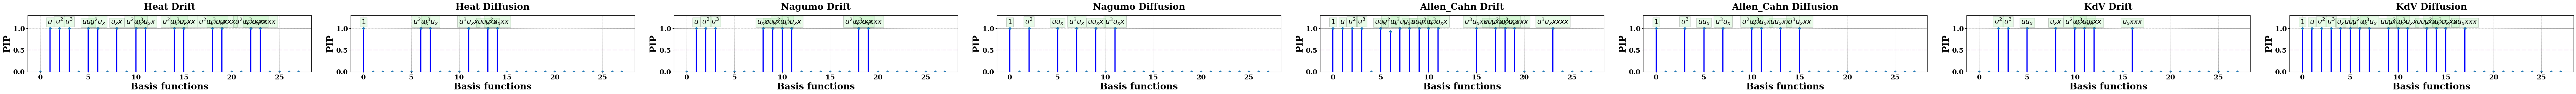

In [8]:
plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 24

fig, axes = plt.subplots(1, len(problemDictionaries) * (2 if (DRIFT and DIFFUSION) else 1), figsize=(12 * len(problemDictionaries) * (2 if (DRIFT and DIFFUSION) else 1), 4))
axes = np.atleast_1d(axes)  # ensures axes is always an array even with 1 subplot

ax_idx = 0
for problem, experimentSet in problemDS.items():
    for identificationTask, DS in experimentSet.items():
        ax = axes[ax_idx]
        ax_idx += 1
        xr = np.array(range(len(DS['zmean'])))

        ax.vlines(xr, 0, DS['zmean'], colors='blue', linewidth=3.0)
        ax.plot(xr, DS['zmean'], 'C0D', markersize=5)
        ax.axhline(y=0.5, color='m', linestyle='-.')

        # annotate discovered terms with PIP > 0.5
        description = problemDescriptions[problem]
        for i, pip in enumerate(DS['zmean']):
            if pip > 0.5:
                label = f"${description[i]}$" if description[i] != '' else '$1$'
                ax.text(i, 1.1, label, bbox=dict(facecolor='lightgreen', alpha=0.2), fontsize=18, ha='center')

        ax.set_xlabel('Basis functions', fontweight='bold', fontsize=24)
        ax.set_ylabel('PIP', fontweight='bold', fontsize=24)
        ax.set_title(f'{problem} {identificationTask}', fontweight='bold', fontsize=24, pad=15)
        ax.grid(color='gray', linestyle='--', linewidth=0.5)
        ax.set_ylim(0, 1.3)
        ax.tick_params(axis='both', labelsize=18)
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontweight('bold')

plt.tight_layout()
plt.show()

### Write Coeffs out to yaml

In [9]:
for problem, experimentSet in problemDS.items():
    for identificationTask, DS in experimentSet.items():
        if not yamlParameters[problem.lower()].get("discovered"):
            yamlParameters[problem.lower()]["discovered"] = {}
        disc = yamlParameters[problem.lower()]["discovered"]
        variances = np.diag(DS['wCOV'])
        
        # map description labels to discovered values and variances
        for i in range(len(DS['zmean'])):
            if DS['zmean'][i] > 0.5:
                description = problemDescriptions[problem]
                label = description[i] if description[i] != '' else '1'
                mean_val = round(float(DS['wmean'][i]), 6)
                var_val  = round(float(variances[i]), 8)
                
                #clean this up it looks terrible - maybe use a dictionary to map labels to yaml keys?
                #probably retrieve how this is done from SPDE.py and use the same mapping here to ensure consistency
                label_to_yaml = {
                    'u_xx': ('epsilon', 'epsilon_variance'),
                    '1': ('sigma_squared', 'sigma_squared_variance'),
                    'u': ('u_coeff', 'u_coeff_variance'),
                    'u^2': ('u2_coeff', 'u2_coeff_variance'),
                    'u^3': ('u3_coeff', 'u3_coeff_variance'), 
                    'uu_x': ('uu_x_coeff', 'uu_x_coeff_variance'),
                    'u_xxx': ('u_xxx_coeff', 'u_xxx_coeff_variance')
                }
                
                if label in label_to_yaml:
                    yaml_key, yaml_variance_key = label_to_yaml[label]
                    disc.setdefault(identificationTask.lower(), {}).setdefault(yaml_key, mean_val)
                    disc[identificationTask.lower()][yaml_variance_key] = var_val

with open("parameters.yaml", "w") as f:
    yaml.dump(yamlParameters, f, default_flow_style=False, sort_keys=False)

### Collinearity Analysis

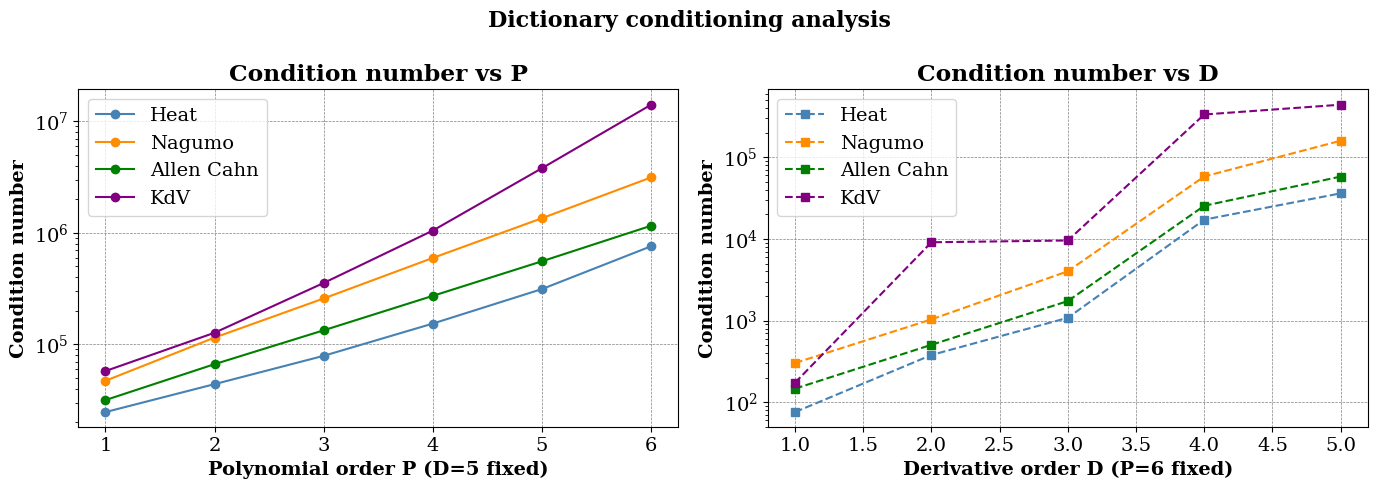

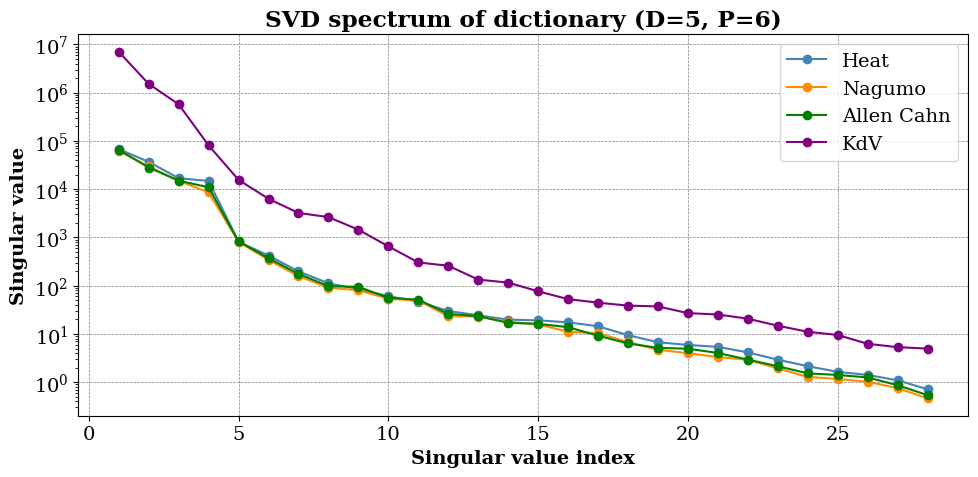


=== Highly correlated pairs (|corr| > 0.80) ===

Heat:
  u vs u^3: 0.9554
  u vs u^2u_xx: -0.9861
  u vs u^2u_xxxx: 0.9854
  u vs u^2u_xxxxxx: -0.9835
  u^2 vs u^3u_xx: -0.9798
  u^2 vs u^3u_xxxx: 0.9735
  u^2 vs u^3u_xxxxxx: -0.9704
  u^3 vs u^2u_xx: -0.9666
  u^3 vs u^2u_xxxx: 0.9480
  u^3 vs u^2u_xxxxxx: -0.9448
  u_x vs u^2u_x: 0.8028
  uu_x vs u^3u_x: 0.9442
  u^2u_xx vs u^2u_xxxx: -0.9941
  u^2u_xx vs u^2u_xxxxxx: 0.9913
  u^3u_xx vs u^3u_xxxx: -0.9944
  u^3u_xx vs u^3u_xxxxxx: 0.9903
  uu_xxx vs u^3u_xxx: 0.8414
  u^3u_xxx vs u^3u_xxxxx: -0.8210
  u_xxxx vs u_xxxxxx: -0.9797
  uu_xxxx vs uu_xxxxxx: -0.9822
  u^2u_xxxx vs u^2u_xxxxxx: -0.9995
  u^3u_xxxx vs u^3u_xxxxxx: -0.9991

Nagumo:
  u vs u^3: 0.9771
  u vs u^2u_xx: -0.9872
  u vs u^2u_xxxx: 0.9863
  u vs u^2u_xxxxxx: -0.9845
  u^2 vs u^3u_xx: -0.9437
  u^2 vs u^3u_xxxx: 0.9342
  u^2 vs u^3u_xxxxxx: -0.9264
  u^3 vs u^2u_xx: -0.9821
  u^3 vs u^2u_xxxx: 0.9742
  u^3 vs u^2u_xxxxxx: -0.9714
  u_x vs u^2u_x: 0.9165
  uu_x vs u

In [15]:
### Beware - a lot of repeated code

plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 14

colors = {'Heat': 'steelblue', 'Nagumo': 'darkorange', 'Allen_Cahn': 'green', 'KdV': 'purple'}

# --- Plot 1: Condition number vs P and D ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for problem in experimentKeys:
    if not experimentKeys[problem]:
        continue
    U = np.load(f'data/{problem}_dx_{spacePoints}m_{timeSteps}t.npy')
    dx = space / U.shape[0]
    dt = timeRange / (U.shape[1] - 1)
    # use first sample only for speed
    u_sample = U[:, :-1, 0]

    # vary P, fix D=5
    cond_vs_P = []
    for P in range(1, 7):
        _, Di, _ = SPDE.build_linear_system(u_sample, dt, dx, D=6, P=P, periodic=isPeriodic, legendre=LEGENDRE_POLYNOMIALS)
        cond_vs_P.append(np.linalg.cond(Di))

    # vary D, fix P=6
    cond_vs_D = []
    for D in range(1, 6):
        _, Di, _ = SPDE.build_linear_system(u_sample, dt, dx, D=D, P=6, periodic=isPeriodic, legendre=LEGENDRE_POLYNOMIALS)
        cond_vs_D.append(np.linalg.cond(Di))

    axes[0].semilogy(range(1, 7), cond_vs_P, 'o-', color=colors[problem], label=problem.replace('_', ' '))
    axes[1].semilogy(range(1, 6), cond_vs_D, 's--', color=colors[problem], label=problem.replace('_', ' '))

axes[0].set_xlabel('Polynomial order P (D=5 fixed)', fontweight='bold')
axes[0].set_ylabel('Condition number', fontweight='bold')
axes[0].set_title('Condition number vs P', fontweight='bold')
axes[0].legend()
axes[0].grid(color='gray', linestyle='--', linewidth=0.5)

axes[1].set_xlabel('Derivative order D (P=6 fixed)', fontweight='bold')
axes[1].set_ylabel('Condition number', fontweight='bold')
axes[1].set_title('Condition number vs D', fontweight='bold')
axes[1].legend()
axes[1].grid(color='gray', linestyle='--', linewidth=0.5)

plt.suptitle('Dictionary conditioning analysis', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig('worthwhileImages/conditioning_vs_PD.pdf', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: SVD spectrum, all three problems overlaid ---
fig, ax = plt.subplots(figsize=(10, 5))

for problem in experimentKeys:
    if not experimentKeys[problem]:
        continue
    _, s, _ = np.linalg.svd(problemDictionaries[problem], full_matrices=False)
    ax.semilogy(range(1, len(s)+1), s, 'o-', color=colors[problem], 
                label=problem.replace('_', ' '))

ax.set_xlabel('Singular value index', fontweight='bold')
ax.set_ylabel('Singular value', fontweight='bold')
ax.set_title('SVD spectrum of dictionary (D=5, P=6)', fontweight='bold')
ax.legend()
ax.grid(color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('worthwhileImages/svd_spectrum.pdf', dpi=150, bbox_inches='tight')
plt.show()

# --- Table: highly correlated pairs ---
print("\n=== Highly correlated pairs (|corr| > 0.80) ===")
for problem in experimentKeys:
    if not experimentKeys[problem]:
        continue
    desc = problemDescriptions[problem][1:]  # skip intercept
    D_mat = problemDictionaries[problem][:, 1:]  # skip intercept column
    corr = np.corrcoef(D_mat.T)
    rows, cols = np.where(np.triu(np.abs(corr), 1) > 0.80)
    print(f"\n{problem}:")
    if len(rows) == 0:
        print("  None")
    for r, c in zip(rows, cols):
        print(f"  {desc[r]} vs {desc[c]}: {corr[r,c]:.4f}")
    
    """
    sort of what you'd expect -  since abs(u) remainsbetween 2 (per plots), even powers behave similary reulgint in high correlations
    we also have that for a smooth periodic function,  the second and fourth derivatives are negatively related - e.g., (sin x and -sin(x)) - recall that initla conditions are sinusoidal and we have periodic bcs
    as a result of fixing the discontinuity at the boundaries and having smooth periodic data, we end up with  pretty much every u_xx and u_xxxx being highly correlated. I guess this means that the sinusoidal effect doesn't really disappear?
    """

smoothness_vals: [np.float64(0.467956070211737), np.float64(0.10614396691385707), np.float64(0.28261831255235526), np.float64(0.053624753169428045)]
corr_vals: [np.float64(0.44334181143031937), np.float64(0.4453180111192334), np.float64(0.46108192412515814), np.float64(0.7513270124198946)]
problem_names: ['Heat', 'Nagumo', 'Allen Cahn', 'KdV']


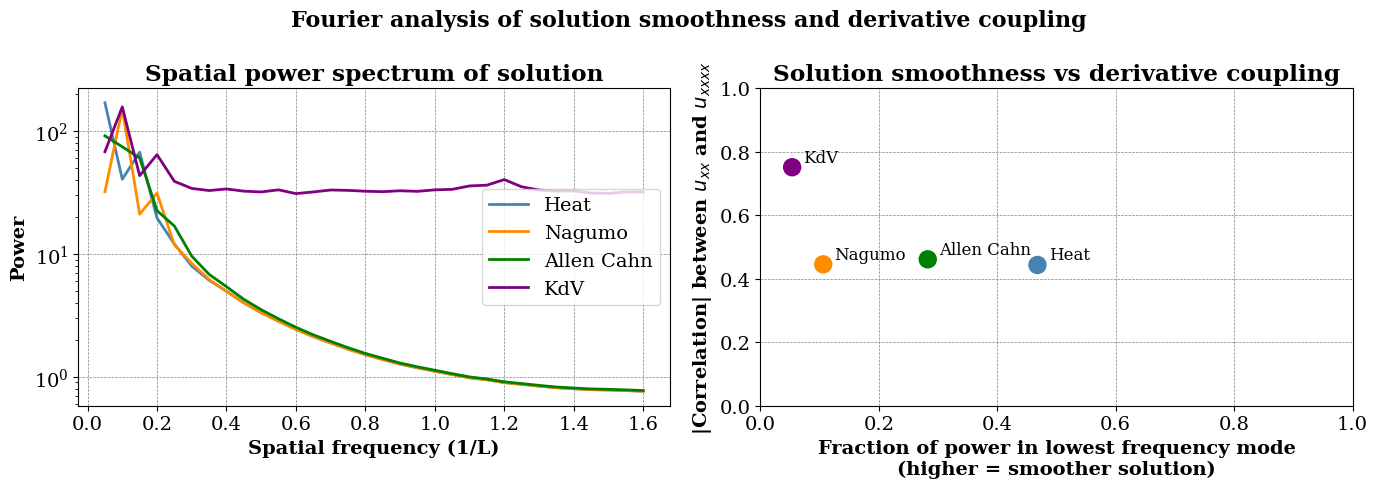


=== Smoothness and derivative coupling ===
Heat: smoothness=0.4680, |corr(u_xx, u_xxxx)|=0.4433
Nagumo: smoothness=0.1061, |corr(u_xx, u_xxxx)|=0.4453
Allen Cahn: smoothness=0.2826, |corr(u_xx, u_xxxx)|=0.4611
KdV: smoothness=0.0536, |corr(u_xx, u_xxxx)|=0.7513


In [16]:
plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 14
colors = {'Heat': 'steelblue', 'Nagumo': 'darkorange', 'Allen_Cahn': 'green', 'KdV': 'purple'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for problem in experimentKeys:
    if not experimentKeys[problem]:
        continue
    
    U = np.load(f'data/{problem}_dx_{spacePoints}m_{timeSteps}t.npy')
    # U shape: (space, time, samples)
    
    # --- Plot 1: spatial power spectrum ---
    # compute FFT along spatial axis for each timestep and sample
    # average power across time and samples to get mean spectrum
    fft_vals = np.fft.rfft(U, axis=0)  # FFT along space axis
    power = np.mean(np.abs(fft_vals)**2, axis=(1, 2))  # average over time and samples
    freqs = np.fft.rfftfreq(U.shape[0], d=dx)
    
    axes[0].semilogy(freqs[1:], power[1:],  # skip DC component (k=0)
                     color=colors[problem], linewidth=2,
                     label=problem.replace('_', ' '))

axes[0].set_xlabel('Spatial frequency (1/L)', fontweight='bold')
axes[0].set_ylabel('Power', fontweight='bold')
axes[0].set_title('Spatial power spectrum of solution', fontweight='bold')
axes[0].legend()
axes[0].grid(color='gray', linestyle='--', linewidth=0.5)

# --- Plot 2: correlation between u_xx and u_xxxx vs smoothness ---
# for each problem, compute:
# (a) fraction of power in lowest frequency mode (measure of smoothness)
# (b) correlation between u_xx and u_xxxx columns in dictionary

smoothness_vals = []
corr_vals = []
problem_names = []
plot_colors = []

for problem in experimentKeys:
    if not experimentKeys[problem]:
        continue
    
    U = np.load(f'data/{problem}_dx_{spacePoints}m_{timeSteps}t.npy')
    
    # smoothness: fraction of total power in k=1 mode
    fft_vals = np.fft.rfft(U, axis=0)
    power = np.mean(np.abs(fft_vals)**2, axis=(1, 2))
    smoothness = power[1] / np.sum(power[1:])
    
    # correlation between u_xx and u_xxxx
    desc = problemDescriptions[problem]
    dictionary = problemDictionaries[problem]
    
    uxx_idx = None
    uxxxx_idx = None
    for i, d in enumerate(desc):
        if (d == 'u_xx') or (d == 'P0(u)u_xx'):  
            uxx_idx = i
        if (d == 'u_xxxx') or (d == 'P0(u)u_xxxx'):  
            uxxxx_idx = i
    
    if uxx_idx is not None and uxxxx_idx is not None:
        corr = np.corrcoef(dictionary[:, uxx_idx], dictionary[:, uxxxx_idx])[0, 1]
        corr_vals.append(abs(corr))
        smoothness_vals.append(smoothness)
        problem_names.append(problem.replace('_', ' '))
        plot_colors.append(colors[problem])
    else:
        print(f"Warning: could not find u_xx and u_xxxx for {problem}")
        print(f"  Available descriptions: {desc}")

print(f"smoothness_vals: {smoothness_vals}")
print(f"corr_vals: {corr_vals}")
print(f"problem_names: {problem_names}")

axes[1].scatter(smoothness_vals, corr_vals,
                c=plot_colors,
                s=150, zorder=5)
for i, name in enumerate(problem_names):
    axes[1].annotate(name, (smoothness_vals[i], corr_vals[i]),
                     textcoords="offset points", xytext=(8, 4), fontsize=12)

axes[1].set_xlabel('Fraction of power in lowest frequency mode\n(higher = smoother solution)', fontweight='bold')
axes[1].set_ylabel('|Correlation| between $u_{xx}$ and $u_{xxxx}$', fontweight='bold')
axes[1].set_title('Solution smoothness vs derivative coupling', fontweight='bold')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].grid(color='gray', linestyle='--', linewidth=0.5)

plt.suptitle('Fourier analysis of solution smoothness and derivative coupling', 
             fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig('worthwhileImages/fourier_smoothness.pdf', dpi=150, bbox_inches='tight')
plt.show()

# print numerical values
print("\n=== Smoothness and derivative coupling ===")
for i, problem in enumerate(problem_names):
    print(f"{problem}: smoothness={smoothness_vals[i]:.4f}, |corr(u_xx, u_xxxx)|={corr_vals[i]:.4f}")

In [17]:
    # per-trajectory correlation: u_xx vs u_xxxx
    # for each trajectory separately, compute correlation across space and time
DO_UXX_UXXXX_CORR = False # for now

if DO_UXX_UXXXX_CORR:
    for key, value in experimentKeys.items():
        if not value:
            continue
        U = np.load(f'data/{key}_dx_{spacePoints}m_{timeSteps}t.npy')
        N = U.shape[0]
        dx = space / U.shape[0]
        per_traj_corrs = []

        for sample in range(U.shape[2]):
            u_traj = U[:, :-1, sample]  # shape (64, 500)
            
            u_xx_traj = np.zeros_like(u_traj)
            u_xxxx_traj = np.zeros_like(u_traj)
            
            for t in range(u_traj.shape[1]):
                u_xx_traj[:, t] = SPDE.FiniteDiff(u_traj[:, t], dx, 2, periodic=True)
                u_xxxx_traj[:, t] = SPDE.FiniteDiff(u_traj[:, t], dx, 4, periodic=True) # just checking, but will probably have to regenerate data with more accurate stencils
            
            corr = np.corrcoef(u_xx_traj.flatten(), u_xxxx_traj.flatten())[0,1]
            per_traj_corrs.append(corr)

        per_traj_corrs = np.array(per_traj_corrs)

        print(f"Per-trajectory correlation u_xx vs u_xxxx:")
        print(f"  Mean: {np.mean(per_traj_corrs):.4f}")
        print(f"  Std:  {np.std(per_traj_corrs):.4f}")
        print(f"  Min:  {np.min(per_traj_corrs):.4f}")
        print(f"  Max:  {np.max(per_traj_corrs):.4f}")

        plt.figure(figsize=(8, 4))
        plt.hist(per_traj_corrs, bins=50)
        plt.xlabel('Per-trajectory correlation (u_xx vs u_xxxx)')
        plt.ylabel('Count')
        plt.title(f'Distribution of per-trajectory correlations - {key}')
        plt.axvline(np.mean(per_traj_corrs), color='red', linestyle='--', label=f'Mean={np.mean(per_traj_corrs):.3f}')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f'worthwhileImages/per_traj_corr_{key.lower()}.pdf', dpi=150, bbox_inches='tight')
        plt.show()

c:\Users\bluem\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\bluem\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


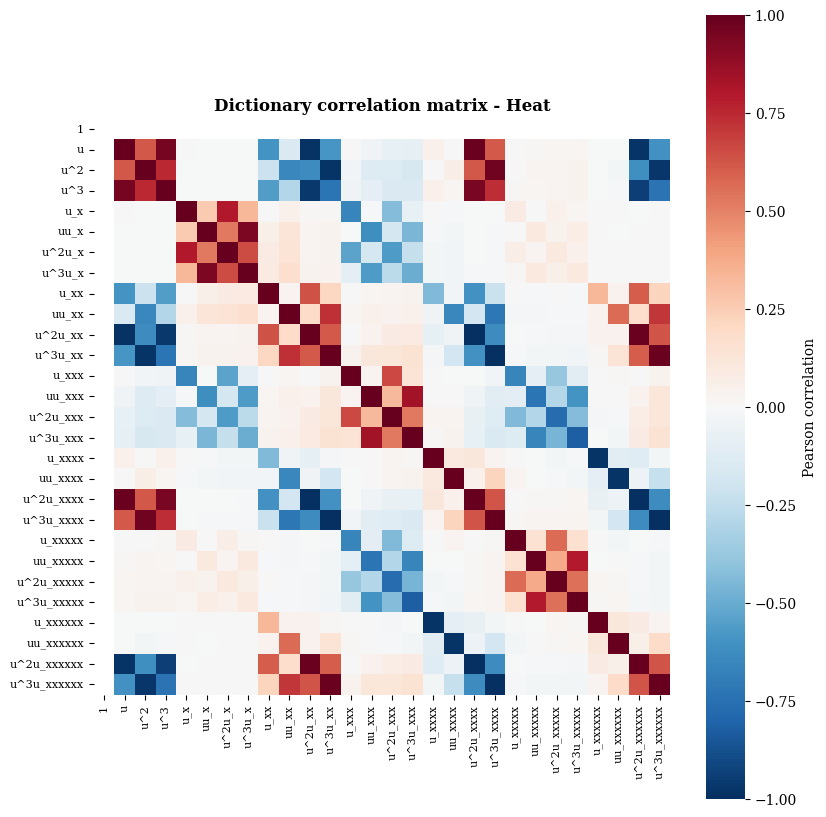

c:\Users\bluem\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\bluem\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


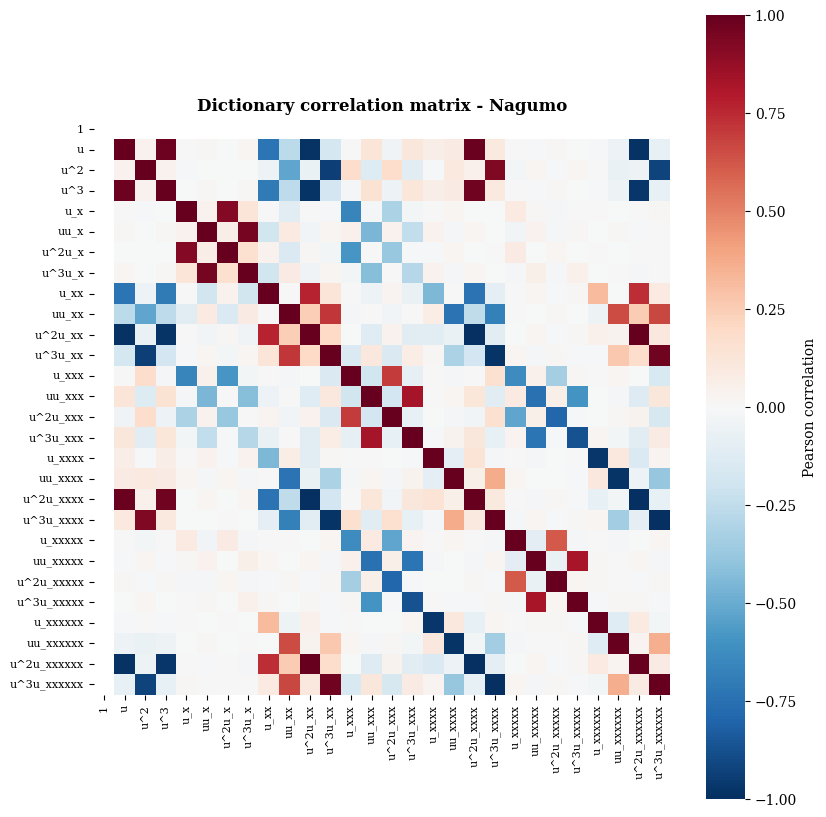

c:\Users\bluem\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\bluem\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


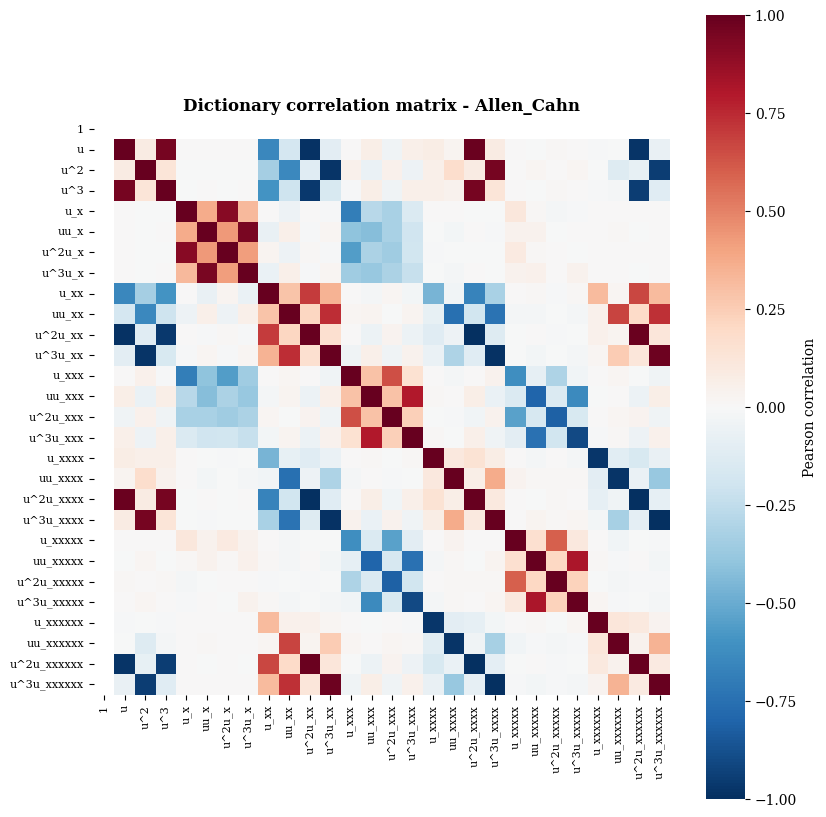

c:\Users\bluem\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\bluem\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


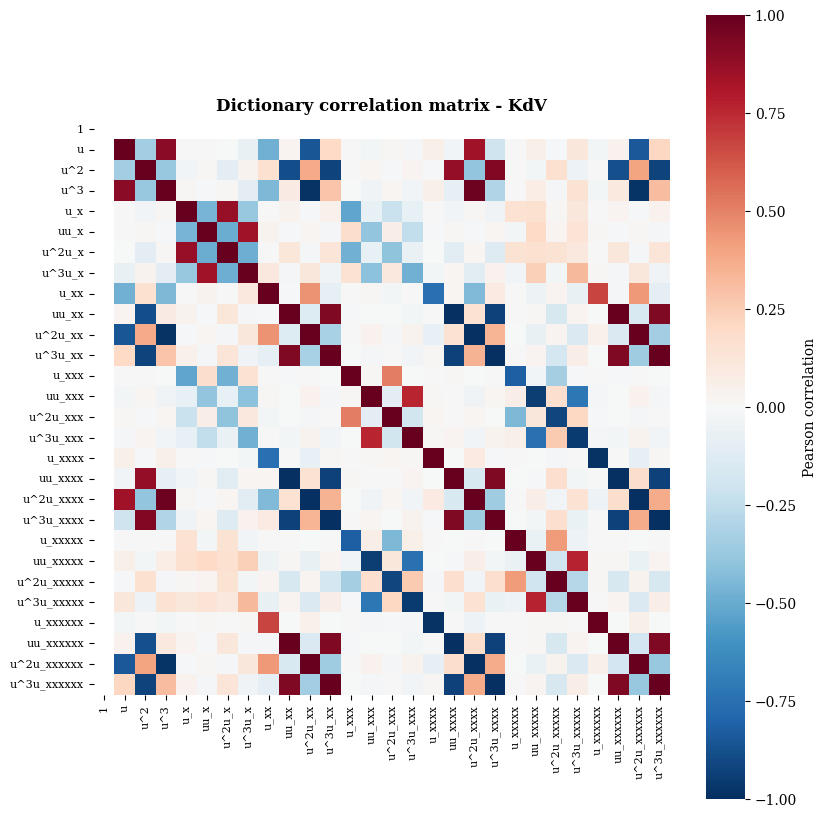

In [18]:
import seaborn as sns

plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 10

for problem in experimentKeys:
    if not experimentKeys[problem]:
        continue

    desc = problemDescriptions[problem]
    dictionary = problemDictionaries[problem]
    corr = np.corrcoef(dictionary.T)

    labels = [d if d != '' else '1' for d in desc]

    fig, ax = plt.subplots(figsize=(max(8, 0.3 * len(desc)), max(8, 0.3 * len(desc))))
    sns.heatmap(
        corr,
        ax=ax,
        cmap='RdBu_r',
        vmin=-1, vmax=1,
        xticklabels=labels,
        yticklabels=labels,
        square=True,
        cbar_kws={'label': 'Pearson correlation'},
    )

    ax.set_title(f'Dictionary correlation matrix - {problem}', fontweight='bold')
    ax.tick_params(axis='x', labelrotation=90, labelsize=8)
    ax.tick_params(axis='y', labelrotation=0, labelsize=8)

    plt.tight_layout()
    plt.savefig(f'worthwhileImages/corr_heatmap_{problem.lower()}.pdf', dpi=150, bbox_inches='tight')
    plt.show()

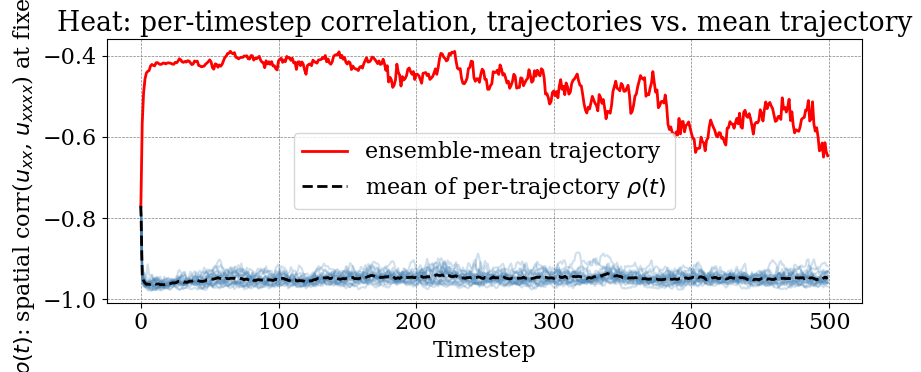


=== Heat ===
Mean-trajectory correlation (flattened space-time): -0.4433
Per-trajectory full-field correlation: mean=-0.9481
Per-trajectory FLUCTUATION-ONLY correlation: mean=-0.9508, std=0.0037


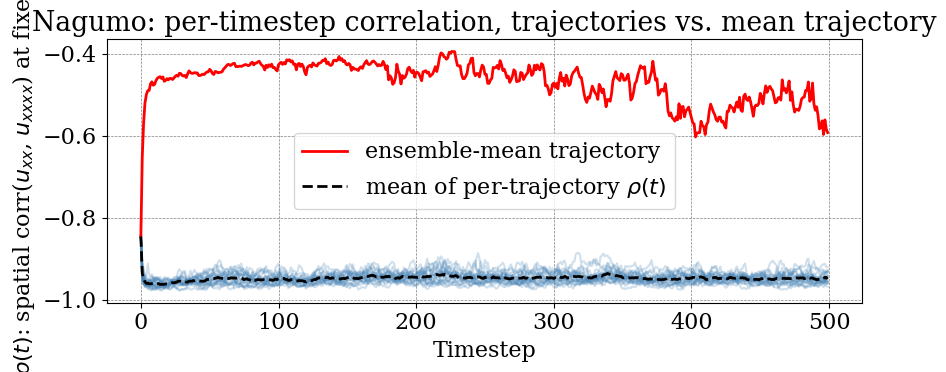


=== Nagumo ===
Mean-trajectory correlation (flattened space-time): -0.4453
Per-trajectory full-field correlation: mean=-0.9480
Per-trajectory FLUCTUATION-ONLY correlation: mean=-0.9507, std=0.0038


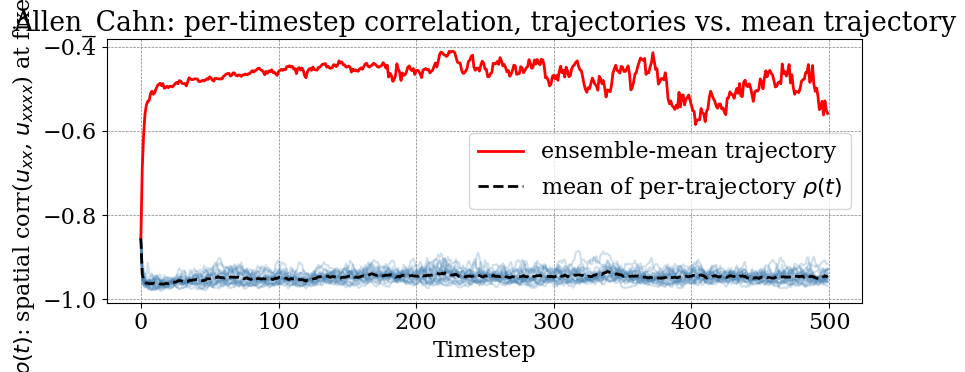


=== Allen_Cahn ===
Mean-trajectory correlation (flattened space-time): -0.4611
Per-trajectory full-field correlation: mean=-0.9467
Per-trajectory FLUCTUATION-ONLY correlation: mean=-0.9491, std=0.0040


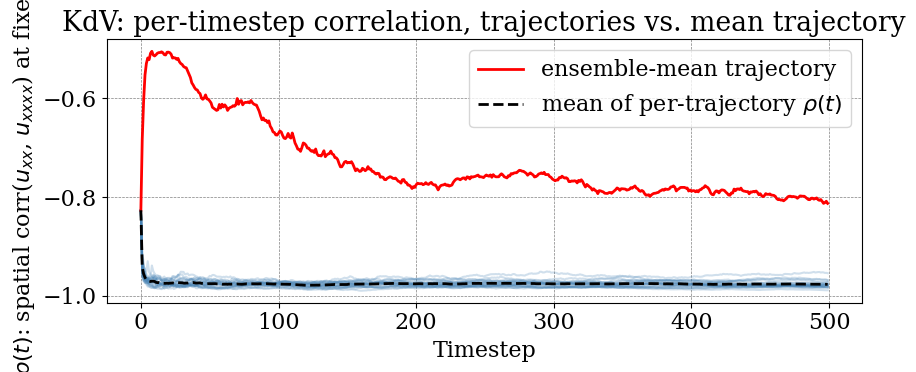


=== KdV ===
Mean-trajectory correlation (flattened space-time): -0.7513
Per-trajectory full-field correlation: mean=-0.9753
Per-trajectory FLUCTUATION-ONLY correlation: mean=-0.9771, std=0.0042


In [29]:
DO_TEMPORAL_CORR_DIAGNOSTIC = True

if DO_TEMPORAL_CORR_DIAGNOSTIC:
    for key, value in experimentKeys.items():
        if not value:
            continue

        u = np.load(f'data/{key}_dx_{spacePoints}m_{timeSteps}t.npy')  # (N, T, samples)
        n = u.shape[0]
        dx = space / n

        uFull = u[:, :-1, :]                      # (N, T, samples)
        uMeanTraj = uFull.mean(axis=2)            # ensemble mean field, (N, T)
        tSteps = uFull.shape[1]

        def derivPerTimestep(traj, derivativeOrder):
            out = np.zeros_like(traj)
            for t in range(traj.shape[1]):
                out[:, t] = SPDE.FiniteDiff(
                    traj[:, t],
                    dx,
                    derivativeOrder,
                    periodic=True
                )
            return out

        # --- Check #1: per-timestep spatial-only correlation rho(t) ---
        nSampleTrajs = min(20, uFull.shape[2])   # a handful of individual trajectories
        rhoTraj = np.zeros((nSampleTrajs, tSteps))

        for sampleIdx in range(nSampleTrajs):
            uxxSample = derivPerTimestep(uFull[:, :, sampleIdx], 2)
            uxxxxSample = derivPerTimestep(uFull[:, :, sampleIdx], 4)

            for t in range(tSteps):
                rhoTraj[sampleIdx, t] = np.corrcoef(
                    uxxSample[:, t],
                    uxxxxSample[:, t]
                )[0, 1]

        uxxMean = derivPerTimestep(uMeanTraj, 2)
        uxxxxMean = derivPerTimestep(uMeanTraj, 4)

        rhoMean = np.array([
            np.corrcoef(uxxMean[:, t], uxxxxMean[:, t])[0, 1]
            for t in range(tSteps)
        ])

        plt.figure(figsize=(9, 4))

        for sampleIdx in range(nSampleTrajs):
            plt.plot(
                rhoTraj[sampleIdx],
                color='steelblue',
                alpha=0.25
            )  # see 3rd line - but not meaned (for every sample)

        plt.plot(
            rhoMean,
            color='red',
            linewidth=2,
            label='ensemble-mean trajectory'
        )  # average trajectories over all samples, then correlations of these

        plt.plot(
            rhoTraj.mean(axis=0),
            color='black',
            linewidth=2,
            linestyle='--',
            label='mean of per-trajectory $\\rho(t)$'
        )  # correlations of each trajectory per time, then mean of these

        plt.xlabel('Timestep')
        plt.ylabel(r'$\rho(t)$: spatial corr($u_{xx}$, $u_{xxxx}$) at fixed $t$')
        plt.title(f'{key}: per-timestep correlation, trajectories vs. mean trajectory')
        plt.legend()
        plt.grid(color='gray', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.savefig(
            f'worthwhileImages/rho_t_{key.lower()}.pdf',
            dpi=150,
            bbox_inches='tight'
        )
        plt.show()

        # --- Check #2: demeaned (fluctuation-only) correlation ---
        nFluctTrajs = min(50, uFull.shape[2])
        fluctCorrs = []

        for sampleIdx in range(nFluctTrajs):
            fluct = uFull[:, :, sampleIdx] - uMeanTraj  # this trajectory's noise component

            uxxFluct = derivPerTimestep(fluct, 2)
            uxxxxFluct = derivPerTimestep(fluct, 4)

            fluctCorrs.append(
                np.corrcoef(
                    uxxFluct.flatten(),
                    uxxxxFluct.flatten()
                )[0, 1]
            )

        fluctCorrs = np.array(fluctCorrs)

        print(f"\n=== {key} ===")
        print(
            f"Mean-trajectory correlation (flattened space-time): "
            f"{np.corrcoef(uxxMean.flatten(), uxxxxMean.flatten())[0, 1]:.4f}"
        )
        print(
            f"Per-trajectory full-field correlation: "
            f"mean={rhoTraj.mean():.4f}"
        )
        print(
            f"Per-trajectory FLUCTUATION-ONLY correlation: "
            f"mean={fluctCorrs.mean():.4f}, std={fluctCorrs.std():.4f}"
        )

# Prediction

Generate data per discovered coefficients

correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


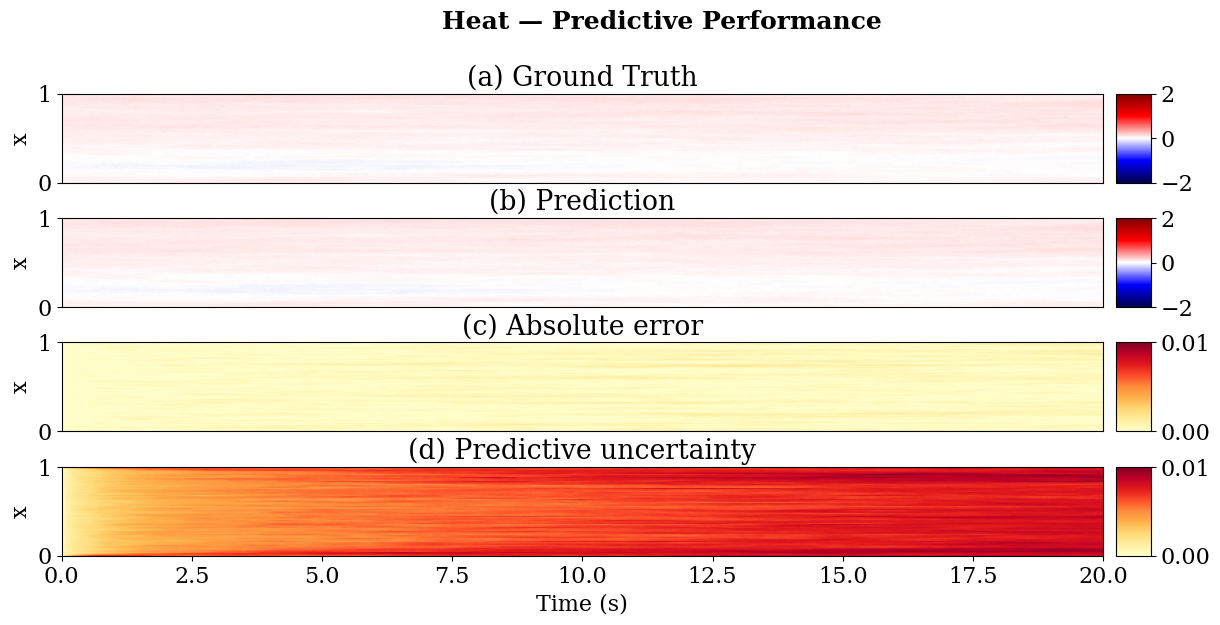

0.009817199573013372
correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


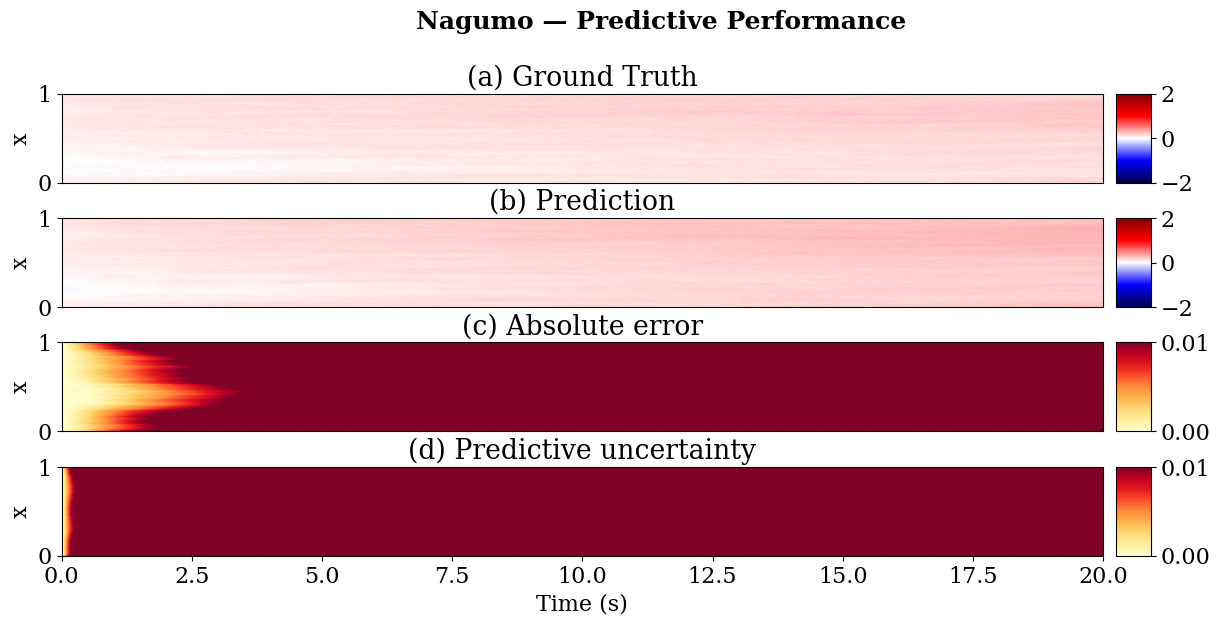

0.20631523403142896
correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


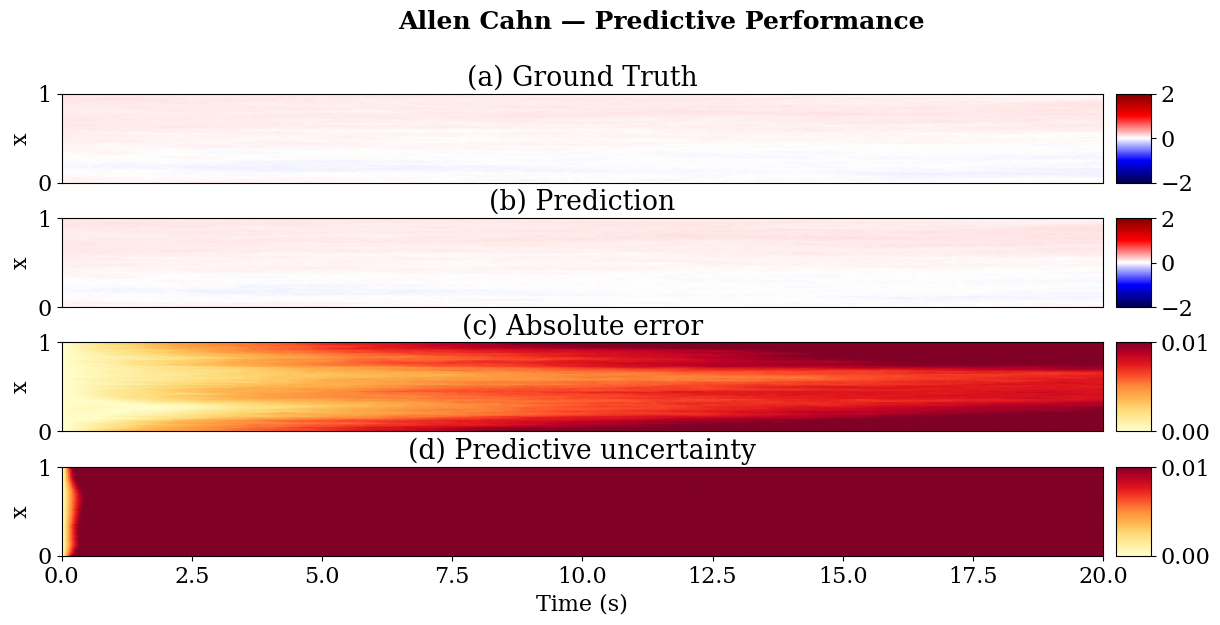

0.07833083994025933


┌ Warning: Verbosity toggle: instability 
│  Instability detected. Aborting
└ @ SciMLBase C:\Users\bluem\.julia\packages\SciMLBase\n5udw\src\integrator_interface.jl:746
┌ Warning: Verbosity toggle: instability 
│  Instability detected. Aborting
└ @ SciMLBase C:\Users\bluem\.julia\packages\SciMLBase\n5udw\src\integrator_interface.jl:746
┌ Warning: Verbosity toggle: instability 
│  Instability detected. Aborting
└ @ SciMLBase C:\Users\bluem\.julia\packages\SciMLBase\n5udw\src\integrator_interface.jl:746
┌ Warning: Verbosity toggle: instability 
│  Instability detected. Aborting
└ @ SciMLBase C:\Users\bluem\.julia\packages\SciMLBase\n5udw\src\integrator_interface.jl:746
┌ Warning: Verbosity toggle: instability 
│  Instability detected. Aborting
└ @ SciMLBase C:\Users\bluem\.julia\packages\SciMLBase\n5udw\src\integrator_interface.jl:746
┌ Warning: Verbosity toggle: instability 
│  Instability detected. Aborting
└ @ SciMLBase C:\Users\bluem\.julia\packages\SciMLBase\n5udw\src\integrator_int

correct sample: 0


┌ Warning: Verbosity toggle: instability 
│  Instability detected. Aborting
└ @ SciMLBase C:\Users\bluem\.julia\packages\SciMLBase\n5udw\src\integrator_interface.jl:746
┌ Warning: Verbosity toggle: instability 
│  Instability detected. Aborting
└ @ SciMLBase C:\Users\bluem\.julia\packages\SciMLBase\n5udw\src\integrator_interface.jl:746
┌ Warning: Verbosity toggle: instability 
│  Instability detected. Aborting
└ @ SciMLBase C:\Users\bluem\.julia\packages\SciMLBase\n5udw\src\integrator_interface.jl:746
┌ Warning: Verbosity toggle: instability 
│  Instability detected. Aborting
└ @ SciMLBase C:\Users\bluem\.julia\packages\SciMLBase\n5udw\src\integrator_interface.jl:746
┌ Warning: Verbosity toggle: instability 
│  Instability detected. Aborting
└ @ SciMLBase C:\Users\bluem\.julia\packages\SciMLBase\n5udw\src\integrator_interface.jl:746
┌ Warning: Verbosity toggle: instability 
│  Instability detected. Aborting
└ @ SciMLBase C:\Users\bluem\.julia\packages\SciMLBase\n5udw\src\integrator_int

ValueError: could not broadcast input array from shape (64,404) into shape (64,501)

┌ Warning: Verbosity toggle: instability 
│  Instability detected. Aborting
└ @ SciMLBase C:\Users\bluem\.julia\packages\SciMLBase\n5udw\src\integrator_interface.jl:746


In [30]:
import PredictionDataGenerator

with open("parameters.yaml") as f:
    yamlParameters = yaml.safe_load(f)

for key, value in experimentKeys.items():
    if value:
        if GENERATE_PREDICTION_DATA:
            PredictionDataGenerator.generatePrediction(key)
        
        U3 = np.load(f'data/{key}_prediction_correct.npy')
        U4 = np.load(f'data/{key}_prediction_pred.npy')
        plt.rcParams['font.size'] = 16

        fig = plt.figure(figsize=(16,6))
        fig.subplots_adjust(wspace=1, hspace=0.4)
        
        solution_cmap = 'seismic'      # diverging for solution fields
        error_cmap = 'YlOrRd'          # sequential for error/uncertainty

        plt.subplot(4,1,1)
        uu = np.mean(U3, axis=2)
        plt.imshow(uu, cmap=solution_cmap, aspect='auto', origin='lower', extent=[0, 20, 0, 1], vmin=-2, vmax=2)
        plt.ylabel('x')
        plt.title('(a) Ground Truth')
        plt.xticks([], [])
        plt.colorbar(aspect=2.5, pad=0.01)

        plt.subplot(4,1,2)
        uu1 = np.mean(U4, axis=2)
        plt.imshow(uu1, cmap=solution_cmap, aspect='auto', origin='lower', extent=[0, 20, 0, 1], vmin=-2, vmax=2)
        plt.ylabel('x')
        plt.title('(b) Prediction')
        plt.xticks([], [])
        plt.colorbar(aspect=2.5, pad=0.01)

        plt.subplot(4,1,3)
        plt.imshow(np.abs(uu - uu1), cmap=error_cmap, aspect='auto', origin='lower', extent=[0, 20, 0, 1], vmin=0, vmax=0.01)
        plt.ylabel('x')
        plt.title('(c) Absolute error')
        plt.xticks([], [])
        plt.colorbar(aspect=2.5, pad=0.01)

        plt.subplot(4,1,4)
        plt.imshow(np.std(U3 - U4, axis=2), cmap=error_cmap, aspect='auto', origin='lower', extent=[0, 20, 0, 1], vmin=0, vmax=0.01)
        plt.xlabel('Time (s)')
        plt.ylabel('x')
        plt.title('(d) Predictive uncertainty')
        plt.colorbar(aspect=2.5, pad=0.01)

        fig.suptitle(f'{key.replace("_", " ").title()} — Predictive Performance', fontweight='bold', fontsize=18, y=1.02)

        plt.show()
        print(np.max(np.std(U3 - U4, axis=2)))
        fig.savefig(f'data/{key}_prediction.pdf', format='pdf', dpi=300, bbox_inches='tight')